In [1]:
# BEFORE importing cupy 
import os

GPU_IDs = [0] # IDs of GPUs that are available (cross-check with gpustat in a terminal)
IDs_txt = ",".join(map(str, GPU_IDs)) # "ID[0],ID[1],ID[2],..."
os.environ["CUDA_VISIBLE_DEVICES"] = IDs_txt # Only these GPUS will be seen by the program after this line 

import numpy 
import cupy as np
import sys,os
from pathlib import Path
import time as time_wall
# Import subroutines
from subroutines import *

# Read input parameters
from parameter import *

In [2]:
import matplotlib.pyplot as plt
#  For loading field
import field_calc

In [3]:
######################
### INITIALIZATION ###
######################
# Set up log
# log = open('./log.txt','a')
# sys.stdout = log

# Create a 'RUNNING.txt' file
with open('./RUNNING.txt', 'w') as creating_new_txt_file:
    pass
print("Empty RUNNING File Created Successfully",flush=True)

# If the seed is fed through an argument, it supersedes the one provided by parameter.py
# num_args = len(sys.argv)
# if num_args>1:
#     seed = int(sys.argv[1])
#     print('Using new seed = %s' % seed, flush = True)

# Initialize random number generator (using numpy because it's faster)
rng = numpy.random.default_rng(seed)

# Builds the wave number and the square wave number matrixes
# In spectral space, index 0 is the kx axis, index 1 is the ky axis
# In real space, index 0 is the x axis, index 1 is the y axis
ka = np.fft.fftfreq(n,d=(1/n)) # kx
ka_half = np.fft.rfftfreq(n,d=(1/n)) # ky
KX,KY = np.meshgrid(ka,ka_half,indexing='ij')
ka2 = KX**2+KY**2
# Imaginary matrix
I = 1j*np.ones((n,n_half),dtype=np.complex128)# If recording triad statistics, load relevant information

if triad_phase_hist:
    # Load triads for histogram
    triads = np.loadtxt(idir+'/triads.txt')
    Ntriads = triads.shape[0]
    print("Gathering histogram statistics for %s triads." % Ntriads, flush = True)

    # Define histogram
    thetauuu = np.zeros((Nbins,Ntriads))
    # Define scriptK
    scriptK = np.zeros((2,Ntriads))
    # Set count to zero for scriptK average
    i_count = 0

    # Now process time-series triads
    triads_ts = np.loadtxt(idir+'/triads_ts.txt')
    Ntriads_ts = triads_ts.shape[0]
    print("Gathering temporal statistics for %s triads." % Ntriads_ts, flush = True)
    
    # Compute index arrays, indKX,indKY,indPX, etc. X arrays have shape (Ntriads,n), Y arrays have shape (n,Ntriads)
    # To be used in thetauuu_calc
    indKX = np.zeros((Ntriads,n))
    indKY = np.zeros((n_half,Ntriads))
    indPX = np.zeros((Ntriads,n))
    indPY = np.zeros((n_half,Ntriads))
    indQX = np.zeros((Ntriads,n))
    indQY = np.zeros((n_half,Ntriads))
    kmag = np.zeros((Ntriads))
    pmag = np.zeros((Ntriads))
    qmag = np.zeros((Ntriads))
    for Ntr,triad in enumerate(triads):
        kx,ky,px,py = triad 
        qx = -kx-px
        qy = -ky-py
        # Magnitudes
        kmag[Ntr] = np.sqrt(kx**2+ky**2)
        pmag[Ntr] = np.sqrt(px**2+py**2)
        qmag[Ntr] = np.sqrt(qx**2+qy**2)
    
        # k
        if (ky>=0): # phi(kx,ky)
            sgn=1.0
        else: # -phi(-kx,-ky)
            ky=-ky
            kx=-kx
            sgn=-1.0
        indKX[Ntr,ka==kx] = sgn
        indKY[ka_half==ky,Ntr] = 1.0
    
        # p
        if (py>=0): # phi(px,py)
            sgn=1.0
        else: # -phi(-px,-py)
            py=-py
            px=-px
            sgn=-1.0
        indPX[Ntr,ka==px] = sgn
        indPY[ka_half==py,Ntr] = 1.0
        
        # q
        if (qy>=0): # phi(qx,qy)
            sgn=1.0
        else: # -phi(-qx,-qy)
            qy=-qy
            qx=-qx
            sgn=-1.0
        indQX[Ntr,ka==qx] = sgn
        indQY[ka_half==qy,Ntr] = 1.0

##########################
### INITIAL CONDITIONS ###
##########################
# Read status.py
stat,time = np.loadtxt('./status.py') # stat is the output number
stat = int(stat)

if stat==0:
    dump = 0 # For use in spectra and transfers
    ini = 1 # Initial time-step
    timet = tstep
    timec = cstep
    times = sstep
    timeth = thstep

    # Stream function IC (random phase up to kup)
    ps = np.zeros((n,n_half),dtype=complex)
    cond = (ka2<=kmax)&(ka2>=tiny)
    phase = rng.uniform(low=-np.pi,high=np.pi,size=ps.shape)
    phase = np.asarray(phase)
    ps[cond] = (np.sqrt(ka2[cond])/kup)**((-alpha-3.0)/2.0) * (np.cos(phase[cond]) + 1j*np.sin(phase[cond]))
    # Ensure 'realness' in the kx = 0 axis:
    ps[n_half:,0] = np.flip(np.conj(ps[1:n_half-1,0]))
    ps[0,0] = ps[n_half-1,0] = 0.0
    
    # Renormalize
    E = energy(ps,1,ka2)
    ps *= np.sqrt(2.0*u0/E)
else:
    ini = int((stat-1)*tstep)
    dump = float(ini)/float(sstep)+1
    times = 0
    timeth = 0
    timet = 0
    timec = 0
    timecorr = 0

    # Load the saved output file
    try:
        R1 = np.load(idir+'/ps.'+f'{int(stat):03}'+'.npy',allow_pickle=True)
    except Exception as e:
        print(e)
        R1 = field_calc.field_calc(idir+'/','ps',f'{int(stat):03}',reso=n)
        
    # FFT to get ps
    ps = np.fft.rfftn(R1)

    # If traid_phase_hist, then load the histogram array
    if triad_phase_hist:
        # Check to see if thetauuu file exists:
        my_file = Path(odir+'/thetauuu.npy')
        if my_file.is_file():
            # Load
            thetauuu[:] = np.load(my_file,allow_pickle=True)[:]

        # Check to see if scriptK file exists:
        my_file = Path(odir+'/scriptK.npy')
        if my_file.is_file():
            # Load
            scriptK[:] = np.load(my_file,allow_pickle=True)[:]

        # Also load the count file, if it exists:
        my_file = Path(odir+'/i_count.npy')
        if my_file.is_file():
            # Load
            i_count = int(np.load(my_file,allow_pickle=True))
            print('Continuing average of scriptK, i_count = %i' % i_count, flush=True)


print('Starting from time-step %s and time %.3f.' % (ini,time), flush=True)

###############
### FORCING ###
###############
dt = CFL_condition(ps,KX,KY,I)
if iflow==1:
    # Stream function forcing (kdn to kup)
    fp = np.zeros((n,n_half),dtype=complex)
    cond = (ka2<=kup**2)&(ka2>=kdn**2)
    if num_args>1:
        # If we're doing an ensemble run, where we change the seed by
        # feeding arguments to the execution, then we add a random
        # phase at the beginning of each run.
        phase = rng.uniform(low=-np.pi,high=np.pi,size=fp.shape)
    else:
        # Otherwise, go with a random phase which is the same for every run.
        rng2 = np.random.default_rng(1)
        phase = rng2.uniform(low=-np.pi,high=np.pi,size=fp.shape)
    phase = np.asarray(phase)
    fp[cond] = (np.cos(phase[cond]) + 1j*np.sin(phase[cond]))
    # Ensure 'realness' in the kx = 0 axis:
    fp[n_half:,0] = np.flip(np.conj(fp[1:n_half-1,0]))
    fp[0,0] = fp[n_half-1,0] = 0.0
    
    # Renormalize
    E = energy(fp,1,ka2)
    fp *= fp0/np.sqrt(E)
    
elif iflow==2:
    fp = const_inj(ps,ka2,rng)
elif iflow==3:
    fp = rand_force(dt,ka2,ka,ka_half,rng)
else:
    sys.exit('ERROR. The variable iflow must be either 1, 2, or 3. Stopping simulation.')

Empty RUNNING File Created Successfully
Gathering histogram statistics for 420 triads.
Gathering temporal statistics for 12 triads.
[Errno 2] No such file or directory: '../ins/ps.002.npy'
Starting from time-step 5000000 and time 0.000.


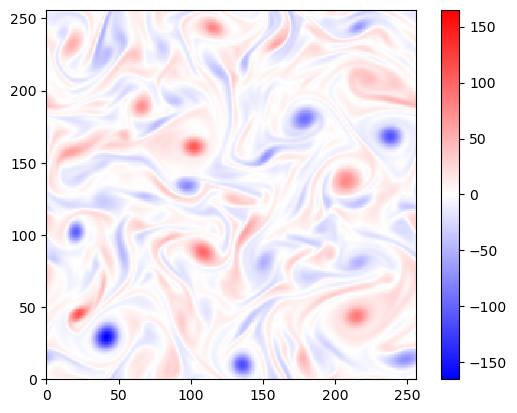

In [4]:
ww = -laplak2(ps,ka2)
im = np.fft.irfftn(ww)
cbar = np.max(np.abs(im))
plt.pcolor(im.get(),vmin=-cbar,vmax=cbar,cmap='bwr')
plt.colorbar()
plt.gca().set_aspect(1)
plt.show()

# Single comparison with CPU

### What do we get with our code?

In [23]:
# Define histogram
thetauuu = np.zeros((Nbins,Ntriads))
scriptK = np.zeros((2,Ntriads))
i_count = 0

In [24]:
i_count,thetauuu,scriptK = thetauuu_calc(ps,i_count,thetauuu,scriptK,ka,ka_half,indKX,indKY,indPX,indPY,indQX,indQY,kmag,pmag,qmag)

### What do we get from the Fortran code?

In [25]:
idir_test = '../../triad_test_CPU_single_2/'

In [26]:
n = 256 #int(runname.split('_')[2])
Nbins = 30

triads = np.loadtxt(idir_test+'/ins/triads.txt')
Ntriads = triads.shape[0]
shape_uuu = (Nbins,Ntriads)
shape_scriptK = (2,Ntriads)


runname = idir_test.split('/')[-1]
# print('------------ '+runname+' ------------')
path = idir_test+'/outs/'

# Reads binary files
file = path+'thetauuu.out'
thetauuu_CPU = field_calc.readhist(file,Nbins*Ntriads)
thetauuu_CPU = np.reshape(thetauuu_CPU,shape_uuu,order='F')
thetauuu_CPU = thetauuu_CPU.astype('float64')


file = path+'scriptK.out'
scriptK_CPU = field_calc.readslice(file,2*Ntriads)
scriptK_CPU = np.reshape(scriptK_CPU,shape_scriptK,order='F')
scriptK_CPU = scriptK_CPU.astype('float64')

In [27]:
np.all(thetauuu_CPU==thetauuu)

array(True)

In [34]:
np.all(np.round(scriptK_CPU,6)==np.round(scriptK,6))

array(True)

In [ ]:
scriptK_CPU[0,:10]

array([ 0.09124795, -0.02805592, -0.03685799, -0.01521566, -0.02459499,
       -0.00937178,  0.03916722, -0.36816017, -0.06403605,  0.04735237])

In [30]:
scriptK[0,:10]

array([ 0.09124794, -0.02805592, -0.03685799, -0.01521566, -0.02459499,
       -0.00937178,  0.03916722, -0.36816017, -0.06403605,  0.04735237])

### What do we get with our old (slow) code?

In [24]:
# Define histogram
thetauuu_v2 = np.zeros((Nbins,Ntriads))
i_count = 0

In [25]:
tmp = 1/n**2
Ntriads = triads.shape[0]

# # Update counter:
# i_count += 1

# Build the bin centers
dtheta = 2*np.pi/Nbins
bins_centered = -np.pi + dtheta/2 + dtheta*np.arange(Nbins)

# Load file listing triads.
# for Ntr,triad in enumerate([triads[3],triads[50],triads[100]]):
for Ntr,triad in enumerate(triads):
    # print('Ntr',Ntr+1)
    kx,ky,px,py = triad
    qx = -kx-px
    qy = -ky-py
    # print('kx,ky',kx,ky)
    # print('px,py',px,py)
    # print('qx,qy',qx,qy)
    # Magnitudes
    kmag = np.sqrt(kx**2+ky**2)
    pmag = np.sqrt(px**2+py**2)
    qmag = np.sqrt(qx**2+qy**2)

    ## Find the phases and calculate theta values
    # k
    if (ky>=0): # phi(kx,ky)
        sgn=1.0
    else: # -phi(-kx,-ky)
        ky=-ky
        kx=-kx
        sgn=-1.0
    phik = sgn*np.angle(ps[ka==kx,ka_half==ky])[0]
    # print('jk',np.where(ka==ky)[0][0]+1)
    # print('ps(k)',ps[ka==ky,ka_half==kx][0])
    # print('phik',phik)

    # p
    if (py>=0): # phi(py,px)
        sgn=1.0
    else: # -phi(-py,-px)
        py=-py
        px=-px
        sgn=-1.0
    phip = sgn*np.angle(ps[ka==px,ka_half==py])[0]
    # print('jp',np.where(ka==py)[0][0]+1)
    # print('phip',phip)
    
    # q
    if (qy>=0): # phi(qy,qx)
        sgn=1.0
    else: # -phi(-qy,-qx)
        qy=-qy
        qx=-qx
        sgn=-1.0
    phiq = sgn*np.angle(ps[ka==qx,ka_half==qy])[0]
    # print('jq',np.where(ka==qy)[0][0]+1)
    # print('phiq',phiq)
    
    # Only add to histogram if rhos > 0:
    # if ((np.abs(ps[ka==ky,ka_half==kx])[0]>0)&(np.abs(ps[ka==py,ka_half==px])[0]>0)&(np.abs(ps[ka==qy,ka_half==qx])[0]>0)):
    if ((np.abs(ps[ka==kx,ka_half==ky])[0])*(np.abs(ps[ka==px,ka_half==py])[0])*(np.abs(ps[ka==qx,ka_half==qy])[0])>0):
        ## Define thetauuu
        theta = phik + phip + phiq
        theta = theta - 2*np.pi*np.round(theta/np.pi/2) # From [-pi,pi]
        # print(phik,phip,phiq,theta)
        # print('theta',theta)
            
        # Find which 'bin' of the theta pdf it should go into and add one to the histogram
        # print('Nbin',np.argmin(np.abs(theta-bins_centered)))
        thetauuu_v2[np.argmin(np.abs(theta-bins_centered)),Ntr] += 1
        
        ### ScriptK average
#         scriptK_tmp = ((qmag**2-pmag**2)/(kmag**2))*((np.abs(ps[ka==qy,ka_half==qx])[0]*np.abs(ps[ka==px,ka_half==py])[0])/(np.abs(ps[ka==kx,ka_half==ky])[0])) + ((pmag**2-kmag**2)/(qmag**2))*((np.abs(ps[ka==py,ka_half==px])[0]*np.abs(ps[ka==ky,ka_half==kx])[0])/(np.abs(ps[ka==qy,ka_half==qx])[0])) + ((kmag**2-qmag**2)/(pmag**2))*((np.abs(ps[ka==ky,ka_half==kx])[0]*np.abs(ps[ka==qy,ka_half==qx])[0])/(np.abs(ps[ka==py,ka_half==px])[0]))
#         # Normalize based on grid
#         scriptK_tmp = scriptK_tmp * tmp
        
#         ## Calculate the mean
#         scriptK_avg_tmp = scriptK[0,Ntr] + (scriptK_tmp - scriptK[0,Ntr])/i_count
        
#         ## Update the variance
#         scriptK[1,Ntr] = scriptK[1,Ntr] + ((scriptK_tmp-scriptK[0,Ntr])*(scriptK_tmp-scriptK_avg_tmp) - scriptK[1,Ntr])/i_count
        
#         ## Update the mean
#         scriptK[0,Ntr] = scriptK_avg_tmp
    else:
        print('ZERO')

In [28]:
np.all(thetauuu_CPU==thetauuu_v2)

array(True)

In [27]:
np.all(thetauuu==thetauuu_v2)

array(False)

In [17]:
print(thetauuu_v2[:,:3]-thetauuu_CPU[:,:3])

[[ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  1. -1.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [-1.  0.  1.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]


# Multiple time-steps. Testing synchronization of threads.

### Original

In [5]:
#################
### MAIN LOOP ###
#################
start_time=time_wall.time()
sim_end = start_time + 60 # run for 60 seconds
step = 9001
t = ini = 1
while (time_wall.time() < sim_end)&(t<=step):
    if (t%cfl_cad)==0: # Update dt every cfl_cad time steps.
        dt = CFL_condition(ps,KX,KY,I)

    # Every 'cstep' steps, outputs global values.  
    # See the cond_check subroutine for details.
    if timec==cstep:
        timec = 0
        cond_check(ps,fp,time,ka2)
        if triad_phase_hist:
            # Output time series of triad energy and p hase for various triads.
            corr_check(ps,time,ka2,ka,ka_half,KX,KY,I,triads_ts)

    # Every 1000 steps, check if RUNNING.txt is present, otherwise end the stepping and save last outputs.
    if (t%1000)==0:
        if not os.path.isfile('./RUNNING.txt'):
            print("RUNNING.txt has been deleted. Stopping run. tstep = %s time = %s" % (t,time),flush=True)
            break

    # Random force
    if iflow==3:
        fp = rand_force(dt,ka2,ka,ka_half,rng)

    # Every 'sstep' steps, generates external files with the power spectrum
    if times==sstep:
        times = 0
        dump += 1 # Update specturm count
        spectrum(ps,dump,ka2)
        transfers(ps,dump,ka2,KX,KY,I)
        with open('./time_spec.txt', 'a') as f:
            f.write(f"{int(dump):04} {time:14.6F}\n")

    # Every 'thstep' steps, calculates and updates thetauuu histogram and scriptK online average (if triad_phase_hist is true)
    if ((timeth==thstep)&(triad_phase_hist)): 
        timeth = 0
        # Updates thetauuu
        i_count,thetauuu,scriptK = thetauuu_calc(ps,i_count,thetauuu,scriptK,ka,ka_half,indKX,indKY,indPX,indPY,indQX,indQY,kmag,pmag,qmag)
        
    # Every 'tstep' steps, stores the results of the integration
    if timet==tstep:
        timet = 0
        stat += 1
        # Write current state to file:
        R1 = np.fft.irfftn(ps)
        np.save(odir+'/ps.'+f'{int(stat):03}'+'.npy',R1)
        
        R1 = np.fft.irfftn(-laplak2(ps,ka2))
        np.save(odir+'/ww.'+f'{int(stat):03}'+'.npy',R1)
        
        # If traid_phase_hist, then overwrites the current thetauuu histogram file. Updates scriptK average file.
        if triad_phase_hist:
            np.save(odir+'/thetauuu.npy',thetauuu)
            np.save(odir+'/scriptK.npy',scriptK)
            np.save(odir+'/i_count.npy',i_count)
            
        
        with open('./time_field.txt', 'a') as f:
            f.write(f"{int(stat):03} {time:14.6F}\n")

    ######## Runge-Kutta step 1
    C3 = np.copy(ps)
    
    ######## Runge-Kutta step 2
    for o in range(ord,0,-1):
        # Iflow2: change forcing to keep constant energy
        if iflow==2:
            fp = const_inj(C3,ka2,rng)
            
        # Nonlinear term
        nl = laplak2(C3,ka2) # Makes -w_2D
        nl = poisson(C3,nl,ka2,KX,KY,I) # Makes -curl(u_2D x w_2D)
        
        tmp1 = dt/float(o)
        C3 = NL(ps,nl,fp,tmp1,nu,hnu,nn,mm,ka2,kmax)
        
    ######## Runge-Kutta step 3
    ps = np.copy(C3)

    # Update times and counters
    t += 1 
    timet += 1
    times += 1
    timeth += 1
    timec += 1
    time += dt   
    
############## END OF MAIN LOOP ##############
end_time=time_wall.time()
print('Finished time-stepping loop. Total wall time: %.4f, iterations per second: %.4f.' % (end_time-start_time,(t-ini)/(end_time-start_time)),flush=True)

Finished time-stepping loop. Total wall time: 21.0910, iterations per second: 426.7692.


In [6]:
thetauuu_original = np.copy(thetauuu)

In [8]:
# np.save('thetauuu_original.npy',thetauuu_original)

### With synchronizing

In [5]:
#################
### MAIN LOOP ###
#################
start_time=time_wall.time()
sim_end = start_time + 60 # run for 60 seconds
step = 9001
t = ini = 1
while (time_wall.time() < sim_end)&(t<=step):
    if (t%cfl_cad)==0: # Update dt every cfl_cad time steps.
        dt = CFL_condition(ps,KX,KY,I)

    # Every 'cstep' steps, outputs global values.  
    # See the cond_check subroutine for details.
    if timec==cstep:
        timec = 0
        cond_check(ps,fp,time,ka2)
        if triad_phase_hist:
            # Output time series of triad energy and p hase for various triads.
            corr_check(ps,time,ka2,ka,ka_half,KX,KY,I,triads_ts)

    # Every 1000 steps, check if RUNNING.txt is present, otherwise end the stepping and save last outputs.
    if (t%1000)==0:
        if not os.path.isfile('./RUNNING.txt'):
            print("RUNNING.txt has been deleted. Stopping run. tstep = %s time = %s" % (t,time),flush=True)
            break

    # Random force
    if iflow==3:
        fp = rand_force(dt,ka2,ka,ka_half,rng)

    # Every 'sstep' steps, generates external files with the power spectrum
    if times==sstep:
        times = 0
        dump += 1 # Update specturm count
        spectrum(ps,dump,ka2)
        transfers(ps,dump,ka2,KX,KY,I)
        with open('./time_spec.txt', 'a') as f:
            f.write(f"{int(dump):04} {time:14.6F}\n")

    # Every 'thstep' steps, calculates and updates thetauuu histogram and scriptK online average (if triad_phase_hist is true)
    if ((timeth==thstep)&(triad_phase_hist)): 
        timeth = 0
        # Updates thetauuu
        np.cuda.Device().synchronize()
        i_count,thetauuu,scriptK = thetauuu_calc(ps,i_count,thetauuu,scriptK,ka,ka_half,indKX,indKY,indPX,indPY,indQX,indQY,kmag,pmag,qmag)
        np.cuda.Device().synchronize()
        
    # Every 'tstep' steps, stores the results of the integration
    if timet==tstep:
        timet = 0
        stat += 1
        # Write current state to file:
        R1 = np.fft.irfftn(ps)
        np.save(odir+'/ps.'+f'{int(stat):03}'+'.npy',R1)
        
        R1 = np.fft.irfftn(-laplak2(ps,ka2))
        np.save(odir+'/ww.'+f'{int(stat):03}'+'.npy',R1)
        
        # If traid_phase_hist, then overwrites the current thetauuu histogram file. Updates scriptK average file.
        if triad_phase_hist:
            np.save(odir+'/thetauuu.npy',thetauuu)
            np.save(odir+'/scriptK.npy',scriptK)
            np.save(odir+'/i_count.npy',i_count)
            
        
        with open('./time_field.txt', 'a') as f:
            f.write(f"{int(stat):03} {time:14.6F}\n")

    ######## Runge-Kutta step 1
    C3 = np.copy(ps)
    
    ######## Runge-Kutta step 2
    for o in range(ord,0,-1):
        # Iflow2: change forcing to keep constant energy
        if iflow==2:
            fp = const_inj(C3,ka2,rng)
            
        # Nonlinear term
        nl = laplak2(C3,ka2) # Makes -w_2D        
        np.cuda.Device().synchronize()
        nl = poisson(C3,nl,ka2,KX,KY,I) # Makes -curl(u_2D x w_2D)
        np.cuda.Device().synchronize()
        
        tmp1 = dt/float(o)
        C3 = NL(ps,nl,fp,tmp1,nu,hnu,nn,mm,ka2,kmax)
        
    ######## Runge-Kutta step 3
    ps = np.copy(C3)

    # Update times and counters
    t += 1 
    timet += 1
    times += 1
    timeth += 1
    timec += 1
    time += dt   
    
############## END OF MAIN LOOP ##############
end_time=time_wall.time()
print('Finished time-stepping loop. Total wall time: %.4f, iterations per second: %.4f.' % (end_time-start_time,(t-ini)/(end_time-start_time)),flush=True)

Finished time-stepping loop. Total wall time: 22.0145, iterations per second: 408.8668.


In [6]:
thetauuu_sync = np.copy(thetauuu)

In [7]:
np.save('thetauuu_sync.npy',thetauuu_sync)

In [8]:
thetauuu_original = np.load('thetauuu_original.npy',allow_pickle=True)

In [9]:
np.all(thetauuu_sync==thetauuu_original)

array(True)

In [10]:
np.sum(thetauuu_sync,axis=0)

array([45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45

In [11]:
np.sum(thetauuu_original,axis=0)

array([45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45.,
       45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45., 45

# Old, random testing

In [114]:
for Ntr,triad in enumerate(triads):
    # print(Ntr,triad)
    kx,ky,px,py = triad
    if Ntr==100:
        print(Ntr,triad)
        ps[ka==ky,ka_half==kx]=0.0+0.0*1j

100 [ 2.  4. -4.  3.]


In [115]:
# Define histogram
thetauuu = np.zeros((Nbins,Ntriads))
thetauuu_v2 = np.zeros((Nbins,Ntriads))
# Define scriptK
scriptK = np.zeros((2,Ntriads))
# Set count to zero for scriptK average
i_count = 1

In [116]:
tmp = 1/n**2

# Build the bin centers
dtheta = 2*np.pi/Nbins
bins_centered = -np.pi + dtheta/2 + dtheta*np.arange(Nbins)

# Isolate individual triad rhos and phis
rhos = np.abs(ps)
rhoks = np.diag(np.dot(np.dot(indKY,rhos),indKX))
rhops = np.diag(np.dot(np.dot(indPY,rhos),indPX))
rhoqs = np.diag(np.dot(np.dot(indQY,rhos),indQX))
phis = np.angle(ps)
phiks = np.diag(np.dot(np.dot(indKY,phis),indKX))
phips = np.diag(np.dot(np.dot(indPY,phis),indPX))
phiqs = np.diag(np.dot(np.dot(indQY,phis),indQX))

####### thetauuu
## Define thetauuu
thetas = phiks+phips+phiqs
thetas = thetas - 2*np.pi*np.round(thetas/np.pi/2) # From [-pi,pi]

# #### Slow version
# for ii,triad in enumerate(triads):
#     if np.abs(rhoks[ii]*rhoqs[ii]*rhops[ii])>0:
#         # Find which 'bin' of the theta pdf it should go into and add one to the histogram
#         thetauuu_v2[np.argmin(np.abs(thetas[ii]-bins_centered)),ii] += 1
#     # else:
#     #     print('cond',ii)
        
#### ChatGPT VERSION
# Remove thetas where one or more rhos == 0.
valid_indices = np.where(np.abs(rhoks*rhoqs*rhops)>0)[0]
thetas_valid = thetas[valid_indices]
# Find which 'bin' of the theta pdf it should go into and add one to the histogram
# Shift thetas to the [0, 2pi) range
shifted_thetas = (thetas_valid + np.pi) % (2 * np.pi)
# Compute bin indices
bin_indices = np.floor(shifted_thetas / dtheta).astype(int)
# Add one to the correct bin in the histogram
thetauuu[bin_indices, valid_indices] += 1

In [107]:
bins_centered

array([-3.0368729 , -2.82743339, -2.61799388, -2.40855437, -2.19911486,
       -1.98967535, -1.78023584, -1.57079633, -1.36135682, -1.15191731,
       -0.9424778 , -0.73303829, -0.52359878, -0.31415927, -0.10471976,
        0.10471976,  0.31415927,  0.52359878,  0.73303829,  0.9424778 ,
        1.15191731,  1.36135682,  1.57079633,  1.78023584,  1.98967535,
        2.19911486,  2.40855437,  2.61799388,  2.82743339,  3.0368729 ])

In [111]:
thetas[51]

array(1.80253688)

In [112]:
thetauuu[:,51]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [105]:
i_count,thetauuu,scriptK = thetauuu_calc(ps,i_count,thetauuu,scriptK,ka,ka_half,indKX,indKY,indPX,indPY,indQX,indQY,kmag,pmag,qmag)

In [126]:
tmp = 1/n**2
Ntriads = triads.shape[0]

# # Update counter:
# i_count += 1

# Build the bin centers
dtheta = 2*np.pi/Nbins
bins_centered = -np.pi + dtheta/2 + dtheta*np.arange(Nbins)

# Load file listing triads.
# for Ntr,triad in enumerate([triads[3],triads[50],triads[100]]):
for Ntr,triad in enumerate(triads):
    # print(Ntr,triad)
    kx,ky,px,py = triad
    qx = -kx-px
    qy = -ky-py
    # Magnitudes
    kmag = np.sqrt(kx**2+ky**2)
    pmag = np.sqrt(px**2+py**2)
    qmag = np.sqrt(qx**2+qy**2)

    ## Find the phases and calculate theta values
    # k
    phik = np.angle(ps[ka==ky,ka_half==kx])[0]

    # p
    if (px>=0): # phi(py,px)
        sgn=1.0
    else: # -phi(-py,-px)
        py=-py
        px=-px
        sgn=-1.0
    phip = sgn*np.angle(ps[ka==py,ka_half==px])[0]
    
    # q
    if (qx>=0): # phi(qy,qx)
        sgn=1.0
    else: # -phi(-qy,-qx)
        qy=-qy
        qx=-qx
        sgn=-1.0
    phiq = sgn*np.angle(ps[ka==qy,ka_half==qx])[0]
    
    # Only add to histogram if rhos > 0:
    # if ((np.abs(ps[ka==ky,ka_half==kx])[0]>0)&(np.abs(ps[ka==py,ka_half==px])[0]>0)&(np.abs(ps[ka==qy,ka_half==qx])[0]>0)):
    if ((np.abs(ps[ka==ky,ka_half==kx])[0])*(np.abs(ps[ka==py,ka_half==px])[0])*(np.abs(ps[ka==qy,ka_half==qx])[0])>0):
        ## Define thetauuu
        theta = phik + phip + phiq
        theta = theta - 2*np.pi*np.round(theta/np.pi/2) # From [-pi,pi]
        # print(phik,phip,phiq,theta)
            
        # Find which 'bin' of the theta pdf it should go into and add one to the histogram
        thetauuu_v2[np.argmin(np.abs(theta-bins_centered)),Ntr] += 1
        
        ### ScriptK average
        scriptK_tmp = ((qmag**2-pmag**2)/(kmag**2))*((np.abs(ps[ka==qy,ka_half==qx])[0]*np.abs(ps[ka==py,ka_half==px])[0])/(np.abs(ps[ka==ky,ka_half==kx])[0])) + ((pmag**2-kmag**2)/(qmag**2))*((np.abs(ps[ka==py,ka_half==px])[0]*np.abs(ps[ka==ky,ka_half==kx])[0])/(np.abs(ps[ka==qy,ka_half==qx])[0])) + ((kmag**2-qmag**2)/(pmag**2))*((np.abs(ps[ka==ky,ka_half==kx])[0]*np.abs(ps[ka==qy,ka_half==qx])[0])/(np.abs(ps[ka==py,ka_half==px])[0]))
        # Normalize based on grid
        scriptK_tmp = scriptK_tmp * tmp
        
        ## Calculate the mean
        scriptK_avg_tmp = scriptK[0,Ntr] + (scriptK_tmp - scriptK[0,Ntr])/i_count
        
        ## Update the variance
        scriptK[1,Ntr] = scriptK[1,Ntr] + ((scriptK_tmp-scriptK[0,Ntr])*(scriptK_tmp-scriptK_avg_tmp) - scriptK[1,Ntr])/i_count
        
        ## Update the mean
        scriptK[0,Ntr] = scriptK_avg_tmp
    else:
        print('ZERO')

(array([255]),)
-1.0
255.0
(array([255]),)
-1.0
255.0
(array([254]),)
-2.0
254.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([253]),)
-3.0
253.0
(array([252]),)
-4.0
252.0
(array([255]),)
-1.0
255.0
(array([255]),)
-1.0
255.0
(array([254]),)
-2.0
254.0
(array([254]),)
-2.0
254.0
(array([253]),)
-3.0
253.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(array([252]),)
-4.0
252.0
(array([253]),)
-3.0
253.0
(array([254]),)
-2.0
254.0
(array([255]),)
-1.0
255.0
(

In [118]:
np.all(thetauuu==thetauuu_v2)

array(True)

In [120]:
print(np.where(thetauuu_v2[:,10]>0))

(array([2]),)


In [121]:
scriptK[:,:10]

array([[-0.03703584, -0.11296711, -0.0445417 ,  0.01974039, -0.03470632,
         0.05204173,  0.01554326, -0.02922614, -0.17413464,  0.00348566],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ]])

In [15]:
Ntriads

118223

In [16]:
%%time
Ntriads = triads.shape[0]

# Build the bin centers
dtheta = 2*np.pi/Nbins
bins_centered = -np.pi + dtheta/2 + dtheta*np.arange(Nbins)

### SHOULD COMPUTE INDICES ONLY ONCE EVERY TIME I DEFINE NEW TRIADS!! Not even at every run. In fact, these arrays should simply be loaded in.
# Compute index arrays, indKX,indKY,indPX, etc. X arrays have shape (Ntriads,n), Y arrays have shape (n,Ntriads)
indKX = np.zeros((n_half,Ntriads))
indKY = np.zeros((Ntriads,n))
indPX = np.zeros((n_half,Ntriads))
indPY = np.zeros((Ntriads,n))
indQX = np.zeros((n_half,Ntriads))
indQY = np.zeros((Ntriads,n))
kmag = np.zeros((Ntriads))
pmag = np.zeros((Ntriads))
qmag = np.zeros((Ntriads))
for Ntr,triad in enumerate(triads):
    kx,ky,px,py = triad
    qx = -kx-px
    qy = -ky-py
    # Magnitudes
    kmag[Ntr] = np.sqrt(kx**2+ky**2)
    pmag[Ntr] = np.sqrt(px**2+py**2)
    qmag[Ntr] = np.sqrt(qx**2+qy**2)

    # k
    indKY[Ntr,ka==ky] = 1.0
    indKX[ka_half==kx,Ntr] = 1.0

    # p
    if (px>=0): # phi(py,px)
        sgn=1.0
    else: # -phi(-py,-px)
        py=-py
        px=-px
        sgn=-1.0
    indPY[Ntr,ka==py] = sgn
    indPX[ka_half==px,Ntr] = 1.0
    
    # q
    if (qx>=0): # phi(qy,qx)
        sgn=1.0
    else: # -phi(-qy,-qx)
        qy=-qy
        qx=-qx
        sgn=-1.0
    indQY[Ntr,ka==qy] = sgn
    indQX[ka_half==qx,Ntr] = 1.0

CPU times: user 2min 10s, sys: 48.9 ms, total: 2min 10s
Wall time: 2min 11s


In [17]:
# Define histogram
thetauuu_2 = np.zeros((Nbins,Ntriads))
# Define scriptK
scriptK_2 = np.zeros((2,Ntriads))
# Update counter:
i_count_2 = 1

In [18]:
%%time
tmp = 1/n**2

# # Update counter:
# i_count_2 += 1

# Isolate individual triad rhos and phis
rhos = np.abs(ps)
rhoks = np.diag(np.dot(np.dot(indKY,rhos),indKX))
rhops = np.diag(np.dot(np.dot(indPY,rhos),indPX))
rhoqs = np.diag(np.dot(np.dot(indQY,rhos),indQX))
phis = np.angle(ps)
phiks = np.diag(np.dot(np.dot(indKY,phis),indKX))
phips = np.diag(np.dot(np.dot(indPY,phis),indPX))
phiqs = np.diag(np.dot(np.dot(indQY,phis),indQX))

####### thetauuu
## Define thetauuu
thetas = phiks+phips+phiqs
thetas = thetas - 2*np.pi*np.round(thetas/np.pi/2) # From [-pi,pi]
# Remove thetas where one or more rhos == 0.
valid_indices = np.where(np.abs(rhoks*rhoqs*rhops)>0)[0]
thetas_valid = thetas[valid_indices]
# Find which 'bin' of the theta pdf it should go into and add one to the histogram
# Shift thetas to the [0, 2pi) range
shifted_thetas = (thetas_valid + np.pi) % (2 * np.pi)
# Compute bin indices
bin_indices = np.floor(shifted_thetas / dtheta).astype(int)
# Add one to the correct bin in the histogram
thetauuu_2[bin_indices, valid_indices] += 1

####### ScriptK average
# scriptK_tmp = ((qmag**2-pmag**2)/(kmag**2))*np.abs((rhoqs*rhops)/(rhoks)) + ((pmag**2-kmag**2)/(qmag**2))*np.abs((rhoks*rhops)/(rhoqs)) + ((kmag**2-qmag**2)/(pmag**2))*np.abs((rhoks*rhoqs)/(rhops))
scriptK_tmp = scriptK_calc(kmag,pmag,qmag,rhoks,rhops,rhoqs)
# Normalize based on grid
scriptK_tmp = scriptK_tmp * tmp

## Calculate the mean
scriptK_avg_tmp = scriptK_2[0,:] + (scriptK_tmp - scriptK_2[0,:])/i_count_2

## Update the variance
scriptK_2[1,:] = scriptK_2[1,:] + ((scriptK_tmp-scriptK_2[0,:])*(scriptK_tmp-scriptK_avg_tmp) - scriptK_2[1,:])/i_count_2

## Update the mean
scriptK_2[0,:] = scriptK_avg_tmp

OutOfMemoryError: Out of memory allocating 111,813,422,080 bytes (allocated so far: 1,309,948,928 bytes).

In [21]:
np.all(np.round(thetauuu,10)==np.round(thetauuu_2,10))

array(True)

In [14]:
np.all(np.round(scriptK_2,10)==np.round(scriptK,10))

array(True)